# P3 - Two-Level Evaluation of Unsupervised Molecular Categorisation

This notebook evaluates the P2 classification result for Helicene_Ag(111)008.sxm through
two linked questions:

1. **How much of the supported classification result is correct?** All five machine-generated
   category totals match the corresponding manual standard-region totals. This gives
   **100% category-count agreement (5 out of 5 category totals)** within the supported scope.
2. **What can the current pipeline not handle?** The preprocessing and segmentation pipeline
   excludes ten molecules touching the image border and three overlapped molecules.

This structure separates classification performance on valid, extracted candidates from the
limitations that occur before reliable classification is possible.

## How to interpret the two-level evaluation

**Level 1 evaluates the supported scope.** The machine counts for P3, P2, Dimer of P1,
Trimer of P1, and Tetramer of P1 are compared with the corresponding manual counts for
standard-region molecules. All five category totals match, so the category-count agreement
rate is 100%.

**Level 2 evaluates pipeline limitations.** Ten border-touching molecules were removed by
clear_border, and three overlapped molecules could not be reliably separated. These thirteen
cases are not treated as wrong class predictions because they never reached reliable
classification.

The phrase **100% category-count agreement** refers to agreement between five aggregate
category totals. It does not prove 100% object-level classification accuracy, because there
is no verified coordinate-level label for every individual candidate.

## 2. Imports and project path discovery

This cell imports the tabular and plotting libraries. It then locates the CountingMolecules
project root by walking upward from the current working directory. This keeps the notebook
runnable when Jupyter is launched from P3 or another directory inside the project.

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "font.size": 10,
})


def find_counting_molecules_root(start=None):
    start_path = Path.cwd() if start is None else Path(start)
    start_path = start_path.resolve()
    for candidate in (start_path, *start_path.parents):
        if (
            (candidate / "project" / "P2").is_dir()
            and (candidate / "project" / "P3" / "data").is_dir()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not locate the CountingMolecules root. "
        "Launch Jupyter from within the CountingMolecules project."
    )


ROOT = find_counting_molecules_root()
P3_DIR = ROOT / "project" / "P3"
OUTPUT_DIR = P3_DIR / "outputs" / "count_level_evaluation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MACHINE_PATH = (
    ROOT
    / "project"
    / "P2"
    / "outputs"
    / "alternative_1_features"
    / "area_perimeter_kmeans"
    / "machine_classification_counts.csv"
)
MANUAL_PATH = P3_DIR / "data" / "manual_observation_counts.csv"
MAPPING_PATH = P3_DIR / "data" / "cluster_category_mapping.csv"

print(f"CountingMolecules root: {ROOT}")
print(f"Evaluation output directory: {OUTPUT_DIR}")

CountingMolecules root: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules
Evaluation output directory: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/project/P3/outputs/count_level_evaluation


## 3. Load the three persisted input tables

The machine table contains machine-generated cluster labels, counts, and cluster centres only.
The manual table contains the human observations. The mapping table is the sole authoritative
source linking C1-C5 to the manual reporting categories.

In [2]:
required_paths = {
    "machine classification counts": MACHINE_PATH,
    "manual observation counts": MANUAL_PATH,
    "cluster-category mapping": MAPPING_PATH,
}
missing = [f"{name}: {path}" for name, path in required_paths.items() if not path.is_file()]
if missing:
    raise FileNotFoundError("Missing required input file(s):\n" + "\n".join(missing))

machine_counts = pd.read_csv(MACHINE_PATH)
manual_counts = pd.read_csv(MANUAL_PATH)
cluster_mapping = pd.read_csv(MAPPING_PATH)

print("Machine counts")
display(machine_counts)
print("Manual observations")
display(manual_counts)
print("Post-hoc reporting mapping")
display(cluster_mapping)

Machine counts


,cluster_id,cluster_label,machine_count,centre_area_nm2,centre_perimeter_nm
0,1,C1,32,1.779366,4.823300
1,2,C2,67,2.122110,5.361627
2,3,C3,106,4.033618,7.850438
3,4,C4,16,6.277466,10.043064
4,5,C5,27,8.025445,11.260920


Manual observations


,manual_category,manual_standard_count,edge_count,overlapped_count,excluded_special_count,manual_total_count,observation_note
0,Dimer of P1,106,8,0,8,114,edge molecules excluded from directly comparab...
1,Trimer of P1,16,1,0,1,17,edge molecules excluded from directly comparab...
2,Tetramer of P1,27,1,0,1,28,edge molecules excluded from directly comparab...
3,P2,67,0,3,3,70,overlapped molecules excluded from directly co...
4,P3,32,0,0,0,32,no documented special cases


Post-hoc reporting mapping


,cluster_id,cluster_label,manual_category,mapping_basis,mapping_role
0,1,C1,P3,matching count and representative single-molec...,posthoc_evaluation_only
1,2,C2,P2,matching count and representative single-molec...,posthoc_evaluation_only
2,3,C3,Dimer of P1,matching count and two-lobe representative mor...,posthoc_evaluation_only
3,4,C4,Trimer of P1,matching count and three-lobe representative m...,posthoc_evaluation_only
4,5,C5,Tetramer of P1,matching count and four-lobe representative mo...,posthoc_evaluation_only


## 4. Validate schemas, keys, values, and scope totals

These checks prevent silent evaluation errors. They enforce exact column contracts, unique
keys, a one-to-one mapping, finite non-negative numeric values, integer count fields, and
reconciliation between standard, excluded, and full manual totals.

In [3]:
MACHINE_COLUMNS = [
    "cluster_id",
    "cluster_label",
    "machine_count",
    "centre_area_nm2",
    "centre_perimeter_nm",
]
MANUAL_COLUMNS = [
    "manual_category",
    "manual_standard_count",
    "edge_count",
    "overlapped_count",
    "excluded_special_count",
    "manual_total_count",
    "observation_note",
]
MAPPING_COLUMNS = [
    "cluster_id",
    "cluster_label",
    "manual_category",
    "mapping_basis",
    "mapping_role",
]

assert list(machine_counts.columns) == MACHINE_COLUMNS, (
    f"Unexpected machine schema: {list(machine_counts.columns)}"
)
assert list(manual_counts.columns) == MANUAL_COLUMNS, (
    f"Unexpected manual schema: {list(manual_counts.columns)}"
)
assert list(cluster_mapping.columns) == MAPPING_COLUMNS, (
    f"Unexpected mapping schema: {list(cluster_mapping.columns)}"
)


def require_nonnegative_integer_columns(frame, columns, table_name):
    for column in columns:
        values = pd.to_numeric(frame[column], errors="raise")
        assert np.isfinite(values.astype(float)).all(), (
            f"{table_name}.{column} contains a non-finite value"
        )
        assert (values >= 0).all(), f"{table_name}.{column} contains a negative value"
        assert np.equal(values, np.floor(values)).all(), (
            f"{table_name}.{column} must contain integers"
        )
        frame[column] = values.astype(int)


require_nonnegative_integer_columns(
    machine_counts,
    ["cluster_id", "machine_count"],
    "machine_counts",
)
require_nonnegative_integer_columns(
    manual_counts,
    [
        "manual_standard_count",
        "edge_count",
        "overlapped_count",
        "excluded_special_count",
        "manual_total_count",
    ],
    "manual_counts",
)
require_nonnegative_integer_columns(
    cluster_mapping,
    ["cluster_id"],
    "cluster_mapping",
)

centres = machine_counts[["centre_area_nm2", "centre_perimeter_nm"]].apply(
    pd.to_numeric,
    errors="raise",
)
assert np.isfinite(centres.to_numpy(dtype=float)).all(), (
    "Machine cluster centres must be finite"
)
assert (centres > 0).all().all(), "Machine cluster centres must be positive"

assert len(machine_counts) == len(manual_counts) == len(cluster_mapping) == 5
assert machine_counts["cluster_id"].is_unique
assert machine_counts["cluster_label"].is_unique
assert manual_counts["manual_category"].is_unique
assert cluster_mapping["cluster_id"].is_unique
assert cluster_mapping["cluster_label"].is_unique
assert cluster_mapping["manual_category"].is_unique
assert set(machine_counts["cluster_id"]) == set(cluster_mapping["cluster_id"])
assert set(machine_counts["cluster_label"]) == set(cluster_mapping["cluster_label"])
assert set(manual_counts["manual_category"]) == set(cluster_mapping["manual_category"])
assert cluster_mapping["mapping_role"].eq("posthoc_evaluation_only").all()

assert (
    manual_counts["excluded_special_count"]
    == manual_counts["edge_count"] + manual_counts["overlapped_count"]
).all()
assert (
    manual_counts["manual_total_count"]
    == manual_counts["manual_standard_count"]
    + manual_counts["excluded_special_count"]
).all()

print("Input schemas, keys, mapping, and row-level count reconciliation are valid.")

Input schemas, keys, mapping, and row-level count reconciliation are valid.


## 5. Align machine clusters with manual reporting categories

The first merge attaches the post-hoc category name from the dedicated mapping table. The
second merge adds the corresponding manual observations. Both merges require one-to-one
keys, so duplicated or missing mappings fail immediately.

In [4]:
comparison = (
    machine_counts.merge(
        cluster_mapping,
        on=["cluster_id", "cluster_label"],
        validate="one_to_one",
    )
    .merge(
        manual_counts,
        on="manual_category",
        validate="one_to_one",
    )
    .sort_values("cluster_id")
    .reset_index(drop=True)
)

assert len(comparison) == 5
display(
    comparison[
        [
            "cluster_label",
            "manual_category",
            "machine_count",
            "manual_standard_count",
            "edge_count",
            "overlapped_count",
        ]
    ]
)

,cluster_label,manual_category,machine_count,manual_standard_count,edge_count,overlapped_count
0,C1,P3,32,32,0,0
1,C2,P2,67,67,0,3
2,C3,Dimer of P1,106,106,8,0
3,C4,Trimer of P1,16,16,1,0
4,C5,Tetramer of P1,27,27,1,0


## 6. Calculate category-level count errors

Count error is machine count minus directly comparable manual standard count. Absolute error
removes the sign, relative error scales by the manual standard count, and exact_count_match
records whether the two aggregate counts are identical for a category.

In [5]:
comparison["count_error"] = (
    comparison["machine_count"]
    - comparison["manual_standard_count"]
)
assert (comparison["manual_standard_count"] > 0).all(), (
    "Relative count error requires positive manual standard counts"
)
comparison["absolute_count_error"] = comparison["count_error"].abs()
comparison["relative_count_error"] = (
    comparison["count_error"]
    / comparison["manual_standard_count"]
)
comparison["exact_count_match"] = comparison["count_error"].eq(0)

display(
    comparison[
        [
            "cluster_label",
            "manual_category",
            "machine_count",
            "manual_standard_count",
            "count_error",
            "absolute_count_error",
            "relative_count_error",
            "exact_count_match",
        ]
    ]
)

,cluster_label,manual_category,machine_count,manual_standard_count,count_error,absolute_count_error,relative_count_error,exact_count_match
0,C1,P3,32,32,0,0,0.0,True
1,C2,P2,67,67,0,0,0.0,True
2,C3,Dimer of P1,106,106,0,0,0.0,True
3,C4,Trimer of P1,16,16,0,0,0.0,True
4,C5,Tetramer of P1,27,27,0,0,0.0,True


# Level 1 - Correct classification results within the supported scope

The current pipeline produced 248 valid standard-region candidates. After applying the
documented post-hoc mapping, every machine category total equals its manual reference total:

- P3: 32 machine vs 32 manual
- P2: 67 machine vs 67 manual
- Dimer of P1: 106 machine vs 106 manual
- Trimer of P1: 16 machine vs 16 manual
- Tetramer of P1: 27 machine vs 27 manual

Therefore, **5 out of 5 category totals match exactly**, giving a
**100% category-count agreement rate**. The category-level mean absolute error is zero and
the total standard-region count error is zero.

This is strong evidence that the clustering result reproduces the manually reported category
distribution for the supported candidates. It remains an aggregate count result, not proof
that every individual molecule has the correct object-level label.

In [6]:
machine_total = int(comparison["machine_count"].sum())
manual_standard_total = int(comparison["manual_standard_count"].sum())
edge_total = int(comparison["edge_count"].sum())
overlap_total = int(comparison["overlapped_count"].sum())
excluded_total = int(comparison["excluded_special_count"].sum())
manual_full_total = int(comparison["manual_total_count"].sum())
category_count_agreement_rate = float(comparison["exact_count_match"].mean())

summary = pd.DataFrame([
    {
        "metric": "category_level_mae",
        "value": comparison["absolute_count_error"].mean(),
        "unit": "molecules",
    },
    {
        "metric": "total_standard_count_error",
        "value": machine_total - manual_standard_total,
        "unit": "molecules",
    },
    {
        "metric": "exact_match_categories",
        "value": int(comparison["exact_count_match"].sum()),
        "unit": "of 5 categories",
    },
    {
        "metric": "category_count_agreement_rate",
        "value": category_count_agreement_rate,
        "unit": "proportion",
    },
    {
        "metric": "edge_exclusions",
        "value": edge_total,
        "unit": "molecules",
    },
    {
        "metric": "overlap_exclusions",
        "value": overlap_total,
        "unit": "molecules",
    },
    {
        "metric": "excluded_special_total",
        "value": excluded_total,
        "unit": "molecules",
    },
    {
        "metric": "full_scene_inclusion_proportion",
        "value": manual_standard_total / manual_full_total,
        "unit": "proportion",
    },
])

assert machine_total == 248
assert manual_standard_total == 248
assert edge_total == 10
assert overlap_total == 3
assert excluded_total == 13
assert manual_full_total == 261
assert comparison["count_error"].eq(0).all()
assert comparison["absolute_count_error"].eq(0).all()
assert np.isfinite(comparison["relative_count_error"]).all()
assert comparison["relative_count_error"].eq(0).all()
assert comparison["exact_count_match"].all()
assert math.isclose(category_count_agreement_rate, 1.0, rel_tol=1e-12)
assert math.isclose(
    manual_standard_total / manual_full_total,
    248 / 261,
    rel_tol=1e-12,
)

display(summary)
print(
    f"Category-count agreement: {category_count_agreement_rate:.2%} "
    f"({int(comparison.exact_count_match.sum())}/5 category totals matched)"
)
print(
    f"Directly comparable manual total: "
    f"{manual_standard_total} / {manual_full_total}"
)
print(
    f"Full-scene inclusion proportion: "
    f"{manual_standard_total / manual_full_total:.2%}"
)
print("This proportion is coverage of the evaluation scope, not classification accuracy.")

,metric,value,unit
0,category_level_mae,0.000000,molecules
1,total_standard_count_error,0.000000,molecules
2,exact_match_categories,5.000000,of 5 categories
3,category_count_agreement_rate,1.000000,proportion
4,edge_exclusions,10.000000,molecules
5,overlap_exclusions,3.000000,molecules
6,excluded_special_total,13.000000,molecules
7,full_scene_inclusion_proportion,0.950192,proportion


Category-count agreement: 100.00% (5/5 category totals matched)
Directly comparable manual total: 248 / 261
Full-scene inclusion proportion: 95.02%
This proportion is coverage of the evaluation scope, not classification accuracy.


## Level 1 evidence - machine counts against manual counts

The grouped bar chart places each machine count beside its directly comparable manual
standard-region count. The paired bars and their value labels coincide in all five categories,
visually supporting the 100% category-count agreement result.

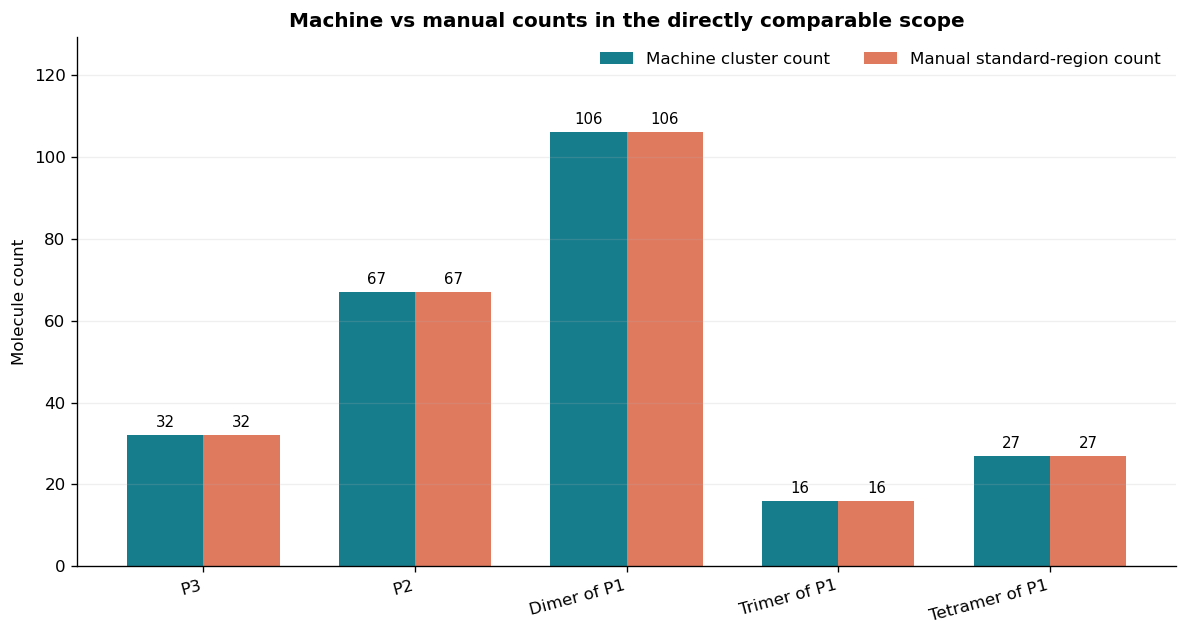

Saved: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/project/P3/outputs/count_level_evaluation/machine_vs_manual_counts.png


In [7]:
categories = comparison["manual_category"].tolist()
x = np.arange(len(categories))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5.4))
machine_bars = ax.bar(
    x - width / 2,
    comparison["machine_count"],
    width,
    label="Machine cluster count",
    color="#167D8D",
)
manual_bars = ax.bar(
    x + width / 2,
    comparison["manual_standard_count"],
    width,
    label="Manual standard-region count",
    color="#E07A5F",
)

ax.bar_label(machine_bars, padding=3, fontsize=9)
ax.bar_label(manual_bars, padding=3, fontsize=9)
ax.set_xticks(x, categories, rotation=15, ha="right")
ax.set_ylabel("Molecule count")
ax.set_title("Machine vs manual counts in the directly comparable scope")
ax.legend(frameon=False, ncols=2, loc="upper right")
ax.set_ylim(0, max(comparison["machine_count"].max(), 106) * 1.22)
ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
comparison_figure_path = OUTPUT_DIR / "machine_vs_manual_counts.png"
fig.savefig(comparison_figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {comparison_figure_path}")

# Level 2 - Limitations of the current pipeline

The full manual reference contains 261 molecules, but only 248 enter the directly comparable
classification scope. The other 13 molecules expose two specific limitations.

## Limitation 1: ten border-touching molecules are removed

The preprocessing pipeline uses clear_border after segmentation. This operation removes every
connected component that touches the image boundary. It does so even when a human observer can
clearly recognise the visible part of the molecule and assign its category.

The ten removed edge cases are:

- eight Dimer of P1 molecules;
- one Trimer of P1 molecule;
- one Tetramer of P1 molecule.

Because these objects are discarded before feature extraction and clustering, the machine
neither counts nor classifies them. This is a preprocessing coverage limitation rather than
evidence of an incorrect cluster label.

## Limitation 2: three overlapped molecules cannot be separated reliably

Three P2 molecules are documented as overlapped. When molecular signals overlap, segmentation
can merge them into an irregular connected region. The current pipeline cannot reliably decide
how many molecules are present or extract an independent feature vector for each one.
Consequently, these three molecules are also outside the supported classification scope.

In total, the pipeline directly covers 248 of 261 manually observed molecules, or 95.02%.
The remaining 13 molecules, or 4.98%, consist of ten border cases and three overlap cases.

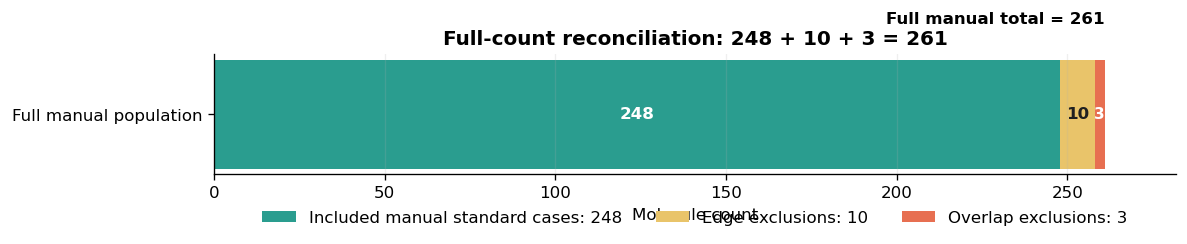

Saved: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/project/P3/outputs/count_level_evaluation/count_reconciliation.png


In [8]:
segments = [
    ("Included manual standard cases", manual_standard_total, "#2A9D8F"),
    ("Edge exclusions", edge_total, "#E9C46A"),
    ("Overlap exclusions", overlap_total, "#E76F51"),
]

fig, ax = plt.subplots(figsize=(10, 3.4))
left = 0
for label, value, color in segments:
    bars = ax.barh(
        ["Full manual population"],
        [value],
        left=left,
        color=color,
        label=f"{label}: {value}",
        height=0.46,
    )
    centre = left + value / 2
    text_color = "white" if label != "Edge exclusions" else "#202020"
    ax.text(
        centre,
        0,
        str(value),
        ha="center",
        va="center",
        color=text_color,
        fontweight="bold",
        fontsize=10 if value >= 10 else 9,
    )
    left += value

ax.set_xlim(0, manual_full_total * 1.08)
ax.set_xlabel("Molecule count")
ax.set_title("Full-count reconciliation: 248 + 10 + 3 = 261")
ax.text(
    manual_full_total,
    0.37,
    f"Full manual total = {manual_full_total}",
    ha="right",
    va="bottom",
    fontweight="bold",
)
ax.legend(frameon=False, ncols=3, loc="lower center", bbox_to_anchor=(0.5, -0.55))
ax.grid(axis="x", alpha=0.2)

fig.tight_layout()
reconciliation_figure_path = OUTPUT_DIR / "count_reconciliation.png"
fig.savefig(reconciliation_figure_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {reconciliation_figure_path}")

## Save the evidence tables

The comparison table records the five exact category-count matches. The summary table records
the 100% category-count agreement rate together with the ten edge exclusions, three overlap
exclusions, and 95.02% full-scene inclusion proportion.

In [9]:
comparison_columns = [
    "cluster_id",
    "cluster_label",
    "machine_count",
    "centre_area_nm2",
    "centre_perimeter_nm",
    "manual_category",
    "mapping_basis",
    "mapping_role",
    "manual_standard_count",
    "edge_count",
    "overlapped_count",
    "excluded_special_count",
    "manual_total_count",
    "observation_note",
    "count_error",
    "absolute_count_error",
    "relative_count_error",
    "exact_count_match",
]
comparison_export = comparison[comparison_columns].copy()
comparison_path = OUTPUT_DIR / "count_comparison_by_category.csv"
summary_path = OUTPUT_DIR / "count_evaluation_summary.csv"

comparison_export.to_csv(comparison_path, index=False)
summary[["metric", "value", "unit"]].to_csv(summary_path, index=False)

reloaded_comparison = pd.read_csv(comparison_path)
reloaded_summary = pd.read_csv(summary_path)
reloaded_values = dict(
    zip(reloaded_summary["metric"], reloaded_summary["value"])
)

assert len(reloaded_comparison) == 5
assert list(reloaded_summary.columns) == ["metric", "value", "unit"]
assert reloaded_comparison["machine_count"].sum() == 248
assert reloaded_comparison["manual_standard_count"].sum() == 248
assert reloaded_comparison["count_error"].eq(0).all()
assert reloaded_comparison["absolute_count_error"].eq(0).all()
assert np.isfinite(reloaded_comparison["relative_count_error"]).all()
assert reloaded_comparison["relative_count_error"].eq(0).all()
assert reloaded_comparison["exact_count_match"].all()
assert reloaded_values["category_level_mae"] == 0
assert reloaded_values["total_standard_count_error"] == 0
assert reloaded_values["exact_match_categories"] == 5
assert math.isclose(
    reloaded_values["category_count_agreement_rate"],
    1.0,
    rel_tol=1e-12,
)
assert reloaded_values["edge_exclusions"] == 10
assert reloaded_values["overlap_exclusions"] == 3
assert reloaded_values["excluded_special_total"] == 13
assert math.isclose(
    reloaded_values["full_scene_inclusion_proportion"],
    248 / 261,
    rel_tol=1e-12,
)

print(f"Saved and revalidated: {comparison_path}")
print(f"Saved and revalidated: {summary_path}")
display(reloaded_comparison)
display(reloaded_summary)

Saved and revalidated: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/project/P3/outputs/count_level_evaluation/count_comparison_by_category.csv
Saved and revalidated: /Volumes/Lexar/01-Active/Learning/monash课程文件/Year2 Semester2/ADS2002/Project/选题/CountingMolecules/project/P3/outputs/count_level_evaluation/count_evaluation_summary.csv


,cluster_id,cluster_label,machine_count,centre_area_nm2,centre_perimeter_nm,manual_category,mapping_basis,mapping_role,manual_standard_count,edge_count,overlapped_count,excluded_special_count,manual_total_count,observation_note,count_error,absolute_count_error,relative_count_error,exact_count_match
0,1,C1,32,1.779366,4.823300,P3,matching count and representative single-molec...,posthoc_evaluation_only,32,0,0,0,32,no documented special cases,0,0,0.0,True
1,2,C2,67,2.122110,5.361627,P2,matching count and representative single-molec...,posthoc_evaluation_only,67,0,3,3,70,overlapped molecules excluded from directly co...,0,0,0.0,True
2,3,C3,106,4.033618,7.850438,Dimer of P1,matching count and two-lobe representative mor...,posthoc_evaluation_only,106,8,0,8,114,edge molecules excluded from directly comparab...,0,0,0.0,True
3,4,C4,16,6.277466,10.043064,Trimer of P1,matching count and three-lobe representative m...,posthoc_evaluation_only,16,1,0,1,17,edge molecules excluded from directly comparab...,0,0,0.0,True
4,5,C5,27,8.025445,11.260920,Tetramer of P1,matching count and four-lobe representative mo...,posthoc_evaluation_only,27,1,0,1,28,edge molecules excluded from directly comparab...,0,0,0.0,True


,metric,value,unit
0,category_level_mae,0.000000,molecules
1,total_standard_count_error,0.000000,molecules
2,exact_match_categories,5.000000,of 5 categories
3,category_count_agreement_rate,1.000000,proportion
4,edge_exclusions,10.000000,molecules
5,overlap_exclusions,3.000000,molecules
6,excluded_special_total,13.000000,molecules
7,full_scene_inclusion_proportion,0.950192,proportion


# Two-level conclusion

## Level 1: supported classification result

For the 248 standard-region candidates in Helicene_Ag(111)008.sxm, all five machine category
totals match the corresponding manual totals. The result is therefore **100% category-count
agreement (5/5 categories)**, with zero category-level MAE and zero total count error.

## Level 2: current limitations

The pipeline does not evaluate all 261 manually observed molecules. The clear_border operation
removes ten visually recognisable border-touching molecules, and the segmentation pipeline
cannot reliably separate three overlapped P2 molecules. These 13 excluded cases reduce the
full-scene inclusion proportion to **95.02%**.

The defensible final statement is therefore: **100% aggregate category-count agreement within
the supported scope, with explicit limitations for border-touching and overlapped molecules.**
This should not be rewritten as 100% object-level classification accuracy unless a future
coordinate-level ground-truth dataset verifies every individual assignment.